# Classification -- Option C + LightGBM

Ajoute **LightGBM** (`LGBMClassifier`) comme nouveau candidat de modele pour la prediction de
la PD, evalue sur le meme perimetre de variables que l'Option C (hybride minimal BFPME) et
compare aux modeles deja etudies :

- RandomForestClassifier
- XGBoost (modele actuellement deploye en production)
- **LightGBM** (nouveau)

Comme les notebooks Option A/B, ce notebook est exploratoire : si LightGBM se revele
superieur (AUC/F1), un script dedie `scripts/train_option_c_lightgbm.py` (sur le meme modele
que `scripts/train_option_c_xgboost.py`) pourra etre cree pour produire un artefact
deployable en remplacement ou en complement du modele XGBoost actuel.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

In [2]:
_cwd = Path.cwd().resolve()
project_root = _cwd.parent if _cwd.name == "notebook" else _cwd
DATA_DIR = project_root / "data"
data_path = DATA_DIR / "final_dataset.csv"
df = pd.read_csv(data_path)
target_col = "default_flag"

# Business feature engineering aligned with data_preprocessing_feature_engineering.ipynb
df["debt_total"] = df["dettes_court_terme"] + df["dettes_long_terme"]
df["loan_to_revenue"] = df["montant_pret"] / df["chiffre_affaires_annuel"].replace(0, np.nan)
df["cash_to_debt"] = df["tresorerie_disponible"] / df["debt_total"].replace(0, np.nan)
df["financement_externe_intensity"] = df["ratio_financement_externe_projet"]
df["impayes_to_loan"] = df["montant_impayes"] / df["montant_pret"].replace(0, np.nan)
df["payment_stress_index"] = (
    np.clip(df["retards_paiement_jours_moyen"] / 90, 0, 3)
    + np.clip(df["impayes_to_loan"], 0, 3)
)
df["fdr_bfr_pressure"] = df["besoin_fonds_roulement_bfr"] / df["fonds_roulement_fdr"].replace(0, np.nan)
df["garantie_to_loan"] = df["valeur_garanties"] / df["montant_pret"].replace(0, np.nan)
df = df.replace([np.inf, -np.inf], np.nan)

# Option C: keep only score_bfpme_global from the BFPME score family.
bfpme_drop = [
    "score_bfpme_good", "score_bfpme_average", "score_bfpme_gap",
    "score_bfpme_global_operational",
    "score_financier", "score_business", "score_management", "score_secteur_industrie",
] + [c for c in df.columns if c.startswith("SF_")]
drop_cols = ["dossier_id", "pd_target"] + bfpme_drop
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col].astype(int)
X.shape

(10000, 52)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

ordinal_map = {
    "duree_credit": ["court_terme", "moyen_terme", "long_terme"],
    "score_global_interne": ["Average Financial", "Good Financial"],
}
ordinal_features = [c for c in ordinal_map if c in X_train.columns]
ordinal_categories = [ordinal_map[c] for c in ordinal_features]

nominal_features = [
    "risk_class", "secteur_activite", "region_localisation", "structure_juridique",
    "classification_pme", "zone_localisation", "type_credit", "objectif_financement",
    "type_taux", "scenario_economique",
]
nominal_features = [c for c in nominal_features if c in X_train.columns]

numeric_features = [c for c in X_train.select_dtypes(include=[np.number]).columns if c not in ordinal_features]

winsor_cols = [
    "montant_pret", "montant_total_investissement", "valeur_garanties", "chiffre_affaires_annuel",
    "total_actif", "total_passif", "capitaux_propres", "dettes_court_terme", "dettes_long_terme",
    "fonds_roulement_fdr", "besoin_fonds_roulement_bfr", "tresorerie_disponible", "montant_impayes",
    "loan_to_revenue", "cash_to_debt", "impayes_to_loan", "fdr_bfr_pressure", "garantie_to_loan",
]
winsor_numeric_features = [c for c in winsor_cols if c in numeric_features]
plain_numeric_features = [c for c in numeric_features if c not in winsor_numeric_features]

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.lower_bounds_ = X.quantile(self.lower_quantile)
        self.upper_bounds_ = X.quantile(self.upper_quantile)
        return self
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(self.lower_bounds_, self.upper_bounds_, axis=1).values

preprocessor = ColumnTransformer(transformers=[
    ("winsor_num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("winsorizer", Winsorizer()), ("scaler", StandardScaler())]), winsor_numeric_features),
    ("plain_num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), plain_numeric_features),
    ("ord", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1))]), ordinal_features),
    ("nom", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), nominal_features),
])

X_train_p = preprocessor.fit_transform(X_train)
X_test_p = preprocessor.transform(X_test)
X_train_p.shape, X_test_p.shape

((8000, 80), (2000, 80))

In [4]:
# final_dataset.csv has no temporal date; models use the stratified random split above.
print("Train/Test shapes:", X_train.shape, X_test.shape)

Train/Test shapes: (8000, 52) (2000, 52)


## Entrainement et comparaison -- RandomForest vs XGBoost vs LightGBM

Les trois modeles sont entraines sur la meme matrice pretraitee (`X_train_p` / `X_test_p`) afin
que la comparaison porte uniquement sur l'algorithme, pas sur le pretraitement.

In [5]:
def evaluate_model(model_name, model, X_train_p, y_train, X_test_p, y_test):
    model.fit(X_train_p, y_train)
    y_pred = model.predict(X_test_p)
    y_prob = model.predict_proba(X_test_p)[:, 1] if hasattr(model, "predict_proba") else y_pred
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob),
    }, confusion_matrix(y_test, y_pred)

rf_model = RandomForestClassifier(
    n_estimators=400, min_samples_split=8, min_samples_leaf=4, random_state=42, n_jobs=-1
)

models = [("RandomForest", rf_model)]

if HAS_XGB:
    xgb_model = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85,
        objective="binary:logistic", eval_metric="auc", random_state=42
    )
    models.append(("XGBoost", xgb_model))

lgbm_model = LGBMClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    num_leaves=31,
    objective="binary",
    random_state=42,
    verbosity=-1,
)
models.append(("LightGBM", lgbm_model))

results, cms = [], {}
for name, model in models:
    res, cm = evaluate_model(name, model, X_train_p, y_train, X_test_p, y_test)
    results.append(res)
    cms[name] = cm

pd.DataFrame(results).sort_values("auc", ascending=False)

,model,accuracy,precision,recall,f1,auc
0,RandomForest,0.8555,0.870599,0.874447,0.872519,0.891187
1,XGBoost,0.8545,0.868421,0.875332,0.871863,0.888968
2,LightGBM,0.8540,0.868306,0.874447,0.871366,0.885073


In [6]:
for model_name, cm in cms.items():
    print(f"\n{model_name} - Confusion Matrix")
    print(cm)


RandomForest - Confusion Matrix
[[722 147]
 [142 989]]

XGBoost - Confusion Matrix
[[719 150]
 [141 990]]

LightGBM - Confusion Matrix
[[719 150]
 [142 989]]


## Interpretabilite -- Permutation importance (LightGBM)

Le preprocesseur et LightGBM sont enchaines dans un seul `Pipeline` afin que la permutation
importance soit mesuree sur les colonnes **originales** (non encodees) de `X_test`, comme pour
RandomForest et XGBoost dans le notebook Option C de reference.

Permutation importance for: LightGBM


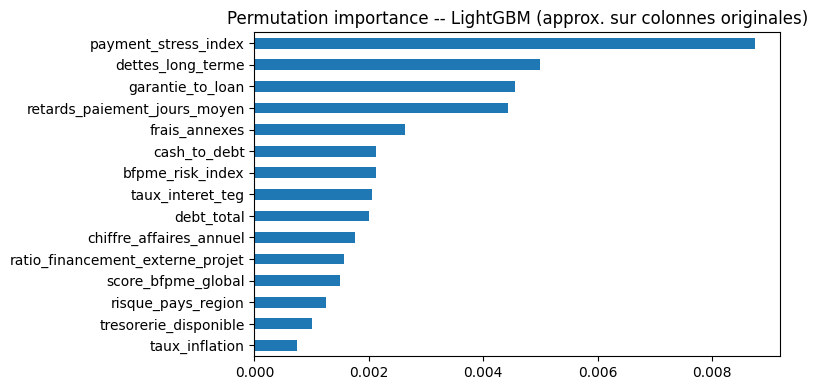

payment_stress_index                0.008750
dettes_long_terme                   0.005000
garantie_to_loan                    0.004562
retards_paiement_jours_moyen        0.004437
frais_annexes                       0.002625
cash_to_debt                        0.002125
bfpme_risk_index                    0.002125
taux_interet_teg                    0.002062
debt_total                          0.002000
chiffre_affaires_annuel             0.001750
ratio_financement_externe_projet    0.001562
score_bfpme_global                  0.001500
risque_pays_region                  0.001250
tresorerie_disponible               0.001000
taux_inflation                      0.000750
dtype: float64

In [7]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

lgbm_pipeline = Pipeline([("preprocessor", preprocessor), ("clf", lgbm_model)])
lgbm_pipeline.fit(X_train, y_train)
print("Permutation importance for: LightGBM")

res_lgbm = permutation_importance(lgbm_pipeline, X_test, y_test, n_repeats=8, random_state=42, n_jobs=-1)
importances_lgbm = pd.Series(res_lgbm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
importances_lgbm.head(15).iloc[::-1].plot(kind="barh")
plt.title("Permutation importance -- LightGBM (approx. sur colonnes originales)")
plt.tight_layout()
plt.show()

importances_lgbm.head(15)

## Conclusion

Le tableau `results` ci-dessus classe RandomForest, XGBoost et LightGBM par AUC decroissante sur
le meme split stratifie (`random_state=42`). Points a verifier avant toute decision de
changement de modele deploye :

- **AUC / F1 / recall** : LightGBM doit apporter un gain net et pas seulement marginal pour
  justifier un changement (le modele XGBoost actuel est deja a ~0.96+ d'AUC sur ce dataset
  synthetique).
- **Stabilite** : re-executer avec 2-3 `random_state` differents pour verifier que l'ecart
  n'est pas du bruit d'echantillonnage.
- **Coherence avec SHAP** : `shap.TreeExplainer` supporte nativement LightGBM, donc la couche
  d'explicabilite (`shap_service.py`) n'aurait pas besoin d'etre modifiee en profondeur si
  LightGBM remplace XGBoost -- seul l'artefact charge par `artifacts.py` changerait.

Si LightGBM est retenu, l'etape suivante est de creer `scripts/train_option_c_lightgbm.py` sur
le meme modele que `scripts/train_option_c_xgboost.py` (memes colonnes, meme preprocesseur,
meme format d'artefact `{model_name, preprocessor, model, allowed_columns}`) afin de produire un
`.joblib` chargeable par le backend via `MODEL_ARTIFACT_PATH`.